Run this cell to download all libraries to build the model.

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn torch joblib
import pickle


Época 0, Loss: 0.3351
Época 10, Loss: 0.2528
Época 20, Loss: 0.1814
Época 30, Loss: 0.1220
Época 40, Loss: 0.0890


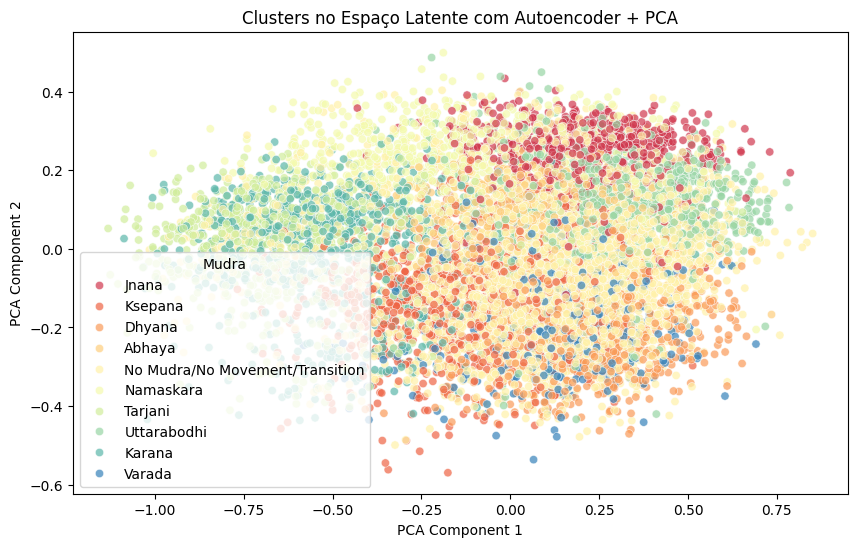

Explained variance ratio: [0.6643233  0.16726445 0.08594776]
Cumulative explained variance: 0.9175
Acurácia: 0.5994363929146538
Relatório de classificação:
                                  precision    recall  f1-score   support

                         Abhaya       0.60      0.54      0.57       552
                         Dhyana       0.43      0.37      0.40       642
                          Jnana       0.65      0.70      0.67       754
                         Karana       0.72      0.77      0.75       724
                        Ksepana       0.61      0.64      0.63       844
                      Namaskara       0.66      0.66      0.66       778
No Mudra/No Movement/Transition       0.59      0.65      0.62      3684
                        Tarjani       0.66      0.73      0.69       639
                    Uttarabodhi       0.53      0.44      0.48       930
                         Varada       0.16      0.03      0.04       389

                       accuracy       

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

df_combined = pd.read_csv('combined_one_hand_data_with_classification.csv')
df_combined = df_combined.dropna(subset=['Mudra'])  # Drop rows without Mudra labels

# Drop specific Mudra categories
df_combined = df_combined[~df_combined['Mudra'].isin(['Vitarka', 'Dharmachakra', 'Bhumisparsa'])]
# Drop left hand columns (13-24)
left_hand_columns = ['L_PositionX', 'L_PositionY', 'L_PositionZ', 'L_RotationX', 'L_RotationY',
                     'L_RotationZ', 'L_RotationW', 'L_CurlIndex', 'L_CurlMiddle', 'L_CurlRing',
                     'L_CurlPinky', 'L_CurlThumb']
df_combined = df_combined.drop(columns=left_hand_columns, errors='ignore')  # Drop left hand columns
# Drop non-numeric columns (keeping only motion data)

df_numeric = df_combined.select_dtypes(include=['number']).drop(columns=['Time'], errors='ignore')

df_numeric = df_numeric.fillna(0)  # Preencher NaN com 0, se necessário
# Visualização dos dados
# Normalizar os dados e salvar o scaler

scaler = MinMaxScaler()
df_normalized = scaler.fit_transform(df_numeric)
joblib.dump(scaler, 'mudra_scaler.joblib')

# Add Gaussian noise to the data
np.random.seed(42)  # For reproducibility
noise_level = 0.20
df_noisy = df_normalized + np.random.normal(0, noise_level, size=df_normalized.shape)
# Ensure values stay in valid range after adding noise
df_noisy = np.clip(df_noisy, 0, 1)

X_train_noisy, X_test_noisy = train_test_split(df_noisy, test_size=0.2, random_state=42)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_noisy, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_noisy, dtype=torch.float32)

# Definição do Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=10):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)  # Compressão para espaço latente
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)  # Reconstrução dos dados originais
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Criar modelo, definir otimizador e função de perda
input_dim = X_train_noisy.shape[1]
autoencoder = Autoencoder(input_dim, latent_dim=10)
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Treinar o Autoencoder
epochs = 50
for epoch in range(epochs):
    optimizer.zero_grad()
    output = autoencoder(X_train_tensor)
    loss = criterion(output, X_train_tensor)  # Comparando reconstrução com entrada
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f'Época {epoch}, Loss: {loss.item():.4f}')

# Salvar o Autoencoder como um arquivo .pth
torch.save(autoencoder.state_dict(), 'mudra_autoencoder_model.pth')

# Get the latent representations
with torch.no_grad():
    X_train_latent = autoencoder.encoder(X_train_tensor).numpy()
    X_test_latent = autoencoder.encoder(X_test_tensor).numpy()

y_train, y_test = train_test_split(df_combined['Mudra'], test_size=0.2, random_state=42)

pca = PCA(n_components=3, random_state=42)
X_pca_train_latent = pca.fit_transform(X_train_latent)
X_pca_test_latent = pca.transform(X_test_latent)

joblib.dump(pca, 'pca_model.pkl')

# Treinar um classificador RandomForest com os dados latentes
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_pca_train_latent, y_train)

# Salvar o classificador RandomForest
joblib.dump(clf, 'mudra_random_forest.joblib')


# Visualize the first two principal components
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_test_latent[:, 0], y=X_pca_test_latent[:, 1], hue=y_test, palette="Spectral", alpha=0.7)
plt.title("Clusters no Espaço Latente com Autoencoder + PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# Print explained variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Cumulative explained variance: {pca.explained_variance_ratio_.sum():.4f}")

# Fazer previsões
y_pred = clf.predict(X_pca_test_latent)

# Avaliação
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Relatório de classificação:\n", classification_report(y_test, y_pred))

Please run the cells above to define the autoencoder and the functions

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Definição do Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=10):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)  # Compressão para espaço latente
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)  # Reconstrução dos dados originais
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [ ]:
def predict_mudra(data, autoencoder=None, clf=None, scaler=None, pca=None):
    """
    Predict the Mudra class for a single data point

    Parameters:
    data: pandas.Series or numpy.ndarray - the input data point
    autoencoder, clf, scaler: pre-loaded models (optional)

    Returns:
    predicted_class: str - the predicted Mudra class
    """
    # Load models if not provided
    if autoencoder is None or clf is None or scaler is None or pca is None:
        autoencoder, clf, scaler, pca = load_models()

    if isinstance(data, pd.DataFrame):
        # If a DataFrame with multiple rows is provided, use only numeric columns
        numeric_data = data.select_dtypes(include=['number'])
        numeric_data = numeric_data.fillna(0)  # Preencher NaN com 0, se necessário
        # Exclude the target column and time column
        if 'Mudra' in numeric_data.columns:
            numeric_data = numeric_data.drop(columns=['Mudra'])
        if 'Time' in numeric_data.columns:
            numeric_data = numeric_data.drop(columns=['Time'])
    elif isinstance(data, pd.Series):
        # If a Series is provided, convert to DataFrame and drop non-numeric values
        numeric_data = pd.DataFrame([data.values], columns=data.index)
        numeric_data = numeric_data.select_dtypes(include=['number'])
        # Exclude the target column and time column
        if 'Mudra' in numeric_data.columns:
            numeric_data = numeric_data.drop(columns=['Mudra'])
        if 'Time' in numeric_data.columns:
            numeric_data = numeric_data.drop(columns=['Time'])
    else:
        # If numpy array, convert to DataFrame
        numeric_data = pd.DataFrame([data])

    # Scale the data
    scaled_data = scaler.transform(numeric_data)

    # Convert to PyTorch tensor
    tensor_data = torch.tensor(scaled_data, dtype=torch.float32)

    # Get latent representation
    with torch.no_grad():
        latent_repr = autoencoder.encoder(tensor_data).numpy()

    latent_repr_tsne = pca.transform(latent_repr)
    # Make prediction

    prediction = clf.predict(latent_repr_tsne)[0]


    return prediction

In [ ]:
def load_models():
    # Load the trained models and scaler
    try:
        # Defina o caminho para o diretório onde o arquivo está localizado
        diretorio = 'Hand_classifier'

        # Construa o caminho completo para o arquivo .pth
        caminho_autoencoder = 'mudra_autoencoder_model.pth'
        caminho_random_forest = 'mudra_random_forest.joblib'
        caminho_scaler = 'mudra_scaler.joblib'
        caminho_pca = 'pca_model.pkl'

        # Load the autoencoder model
        autoencoder = Autoencoder(input_dim=12, latent_dim=10)
        autoencoder.load_state_dict(torch.load(caminho_autoencoder))
        autoencoder.eval()  # Set to evaluation mode

        # Load the Random Forest classifier
        clf = joblib.load(caminho_random_forest)

        # Load the scaler
        scaler = joblib.load(caminho_scaler)

        # Load the t-SNE model
        pca = joblib.load(caminho_pca)
        # Check if models are loaded correctly
        if autoencoder is None or clf is None or scaler is None or pca is None:
            raise ValueError("One or more models failed to load.")
        print("Models loaded successfully.")
        # Return the loaded models
        return autoencoder, clf, scaler, pca

    except Exception as e:
        print(f"Error loading models: {e}")
        return None, None, None

In [ ]:
import json
import pandas as pd
import numpy as np
from datetime import datetime
import joblib



def test_with_sample_from_csv_and_save_json(csv_path, num_tests=10000, json_output_path="test_results.json"):
    """
    Test the prediction function with multiple random samples from a CSV file and save results to JSON
    Parameters:
    csv_path: str - path to the CSV file
    num_tests: int - number of random predictions to make
    json_output_path: str - path to save the JSON results file
    Returns:
    success_count: int - number of correct predictions
    fail_count: int - number of incorrect predictions
    success_rate: float - percentage of correct predictions
    """
    try:
        # Load models
        autoencoder, clf, scaler, pca = load_models()

        # Load the CSV file
        df = pd.read_csv(csv_path)
        df = df[~df['Mudra'].isin(['Vitarka', 'Dharmachakra', 'Bhumisparsa'])]
        left_hand_columns = ['L_PositionX', 'L_PositionY', 'L_PositionZ', 'L_RotationX', 'L_RotationY',
                     'L_RotationZ', 'L_RotationW', 'L_CurlIndex', 'L_CurlMiddle', 'L_CurlRing',
                     'L_CurlPinky', 'L_CurlThumb']
        df = df.drop(columns=left_hand_columns, errors='ignore')
        df.fillna(0, inplace=True)

        # Initialize counters and storage
        success_count = 0
        fail_count = 0
        sample_details = []

        # Perform multiple random predictions
        for i in range(num_tests):
            # Get a random row
            random_index = np.random.randint(0, len(df))
            sample = df.iloc[random_index]

            # Make prediction
            prediction = predict_mudra(sample, autoencoder, clf, scaler, pca)

            # Get actual class
            actual_class = sample.get('Mudra', "Unknown")

            # Check if prediction is correct
            is_correct = prediction == actual_class
            if is_correct:
                success_count += 1
                result = "Correct"
            else:
                fail_count += 1
                result = "Wrong"

            # Store first 50 samples with detailed information
            if i < 50:
                # Convert sample data to dictionary (excluding 'Mudra' column for features)
                sample_data = sample.drop('Mudra').to_dict() if 'Mudra' in sample.index else sample.to_dict()

                sample_detail = {
                    "test_number": i + 1,
                    "csv_row_index": int(random_index),
                    "sample_data": {k: float(v) if pd.api.types.is_numeric_dtype(type(v)) else str(v) for k, v in sample_data.items()},
                    "prediction": prediction,
                    "ground_truth": actual_class,
                    "is_correct": is_correct,
                    "result": result
                }
                sample_details.append(sample_detail)

            # Print results for monitoring
            print(f"Test {i+1} (Index {random_index}):")
            print(f"Predicted: {prediction}")
            print(f"Actual: {actual_class}")
            print(f"Result: ✓ {result}")

        # Calculate success rate
        success_rate = (success_count / num_tests) * 100 if num_tests > 0 else 0

        # Prepare JSON data
        json_data = {
            "test_metadata": {
                "csv_file": csv_path,
                "total_tests": num_tests,
                "test_date": datetime.now().isoformat(),
                "samples_stored": len(sample_details)
            },
            "final_scores": {
                "success_count": success_count,
                "fail_count": fail_count,
                "success_rate": round(success_rate, 2),
                "total_samples": num_tests
            },
            "sample_details": sample_details
        }

        # Save to JSON file
        with open(json_output_path, 'w', encoding='utf-8') as f:
            json.dump(json_data, f, indent=2, ensure_ascii=False)

        # Print summary
        print(f"\nSummary:")
        print(f"Success: {success_count} points")
        print(f"Failures: {fail_count} points")
        print(f"Success Rate: {success_rate:.2f}%")
        print(f"Results saved to: {json_output_path}")

        return success_count, fail_count, success_rate

    except Exception as e:
        print(f"Error during prediction: {e}")
        # Save error information to JSON as well
        error_data = {
            "error": True,
            "error_message": str(e),
            "test_date": datetime.now().isoformat(),
            "final_scores": {
                "success_count": 0,
                "fail_count": 0,
                "success_rate": 0.0,
                "total_samples": 0
            }
        }

        try:
            with open(json_output_path, 'w', encoding='utf-8') as f:
                json.dump(error_data, f, indent=2, ensure_ascii=False)
        except:
            pass

        return 0, 0, 0

# Usage example:
#success, fail, rate = test_with_sample_from_csv_and_save_json("combined_one_hand_data_with_classification.csv", 10000, "mudra_test_results.json")

In [ ]:
success, fail, rate = test_with_sample_from_csv_and_save_json("combined_one_hand_data_with_classification.csv", 50, "mudra_test_results.json")

Models loaded successfully.
Test 1 (Index 38641):
Predicted: No Mudra/No Movement/Transition
Actual: No Mudra/No Movement/Transition
Result: ✓ Correct
Test 2 (Index 38643):
Predicted: No Mudra/No Movement/Transition
Actual: No Mudra/No Movement/Transition
Result: ✓ Correct
Test 3 (Index 44542):
Predicted: Namaskara
Actual: No Mudra/No Movement/Transition
Result: ✓ Wrong
Test 4 (Index 36607):
Predicted: Karana
Actual: Karana
Result: ✓ Correct
Test 5 (Index 34646):
Predicted: No Mudra/No Movement/Transition
Actual: No Mudra/No Movement/Transition
Result: ✓ Correct
Test 6 (Index 39379):
Predicted: No Mudra/No Movement/Transition
Actual: No Mudra/No Movement/Transition
Result: ✓ Correct
Test 7 (Index 43834):
Predicted: No Mudra/No Movement/Transition
Actual: Namaskara
Result: ✓ Wrong
Test 8 (Index 36683):
Predicted: Karana
Actual: Karana
Result: ✓ Correct
Test 9 (Index 12425):
Predicted: No Mudra/No Movement/Transition
Actual: No Mudra/No Movement/Transition
Result: ✓ Correct
Test 10 (Inde